# CardioTwin Baseline Models

IIT Multimodal AI Hackathon 2026 Track A.

This notebook builds leakage-safe baseline benchmarks for four binary targets: CAD, LAD, LCX, and RCA.
It compares conservative model families using repeated stratified cross-validation and out-of-fold
predictions. It does **not** perform aggressive hyperparameter optimization, SMOTE, augmentation,
global feature selection, threshold tuning, target-as-predictor modeling, or final model saving.

In [1]:
from __future__ import annotations

import json
import math
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
N_SPLITS = 5
N_REPEATS = 5
FORBIDDEN_COLUMNS = {"LAD", "LCX", "RCA", "Cath"}
TARGETS = ["cad", "lad", "lcx", "rca"]
SERIOUS_MODELS = {
    "logreg_l2",
    "logreg_l2_balanced",
    "random_forest",
    "random_forest_balanced",
    "extra_trees",
    "extra_trees_balanced",
    "xgboost",
    "xgboost_weighted",
    "lightgbm",
    "lightgbm_weighted",
    "catboost",
    "catboost_balanced",
}

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 220)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

notebook_start = time.perf_counter()


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "ml" / "data" / "processed").exists():
            return candidate
        if candidate.name == "ml" and (candidate / "data" / "processed").exists():
            return candidate.parent
    raise FileNotFoundError("Could not locate project root containing ml/data/processed.")


PROJECT_ROOT = find_project_root()
ML_DIR = PROJECT_ROOT / "ml"
PROCESSED_DIR = ML_DIR / "data" / "processed"
BASELINE_DIR = ML_DIR / "artifacts" / "metrics" / "baselines"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

X = pd.read_csv(PROCESSED_DIR / "features_clean.csv")
y = pd.read_csv(PROCESSED_DIR / "targets_clean.csv")
feature_metadata = pd.read_csv(PROCESSED_DIR / "feature_metadata.csv")

numeric_features = feature_metadata.loc[feature_metadata["feature_type"].eq("numeric"), "feature"].tolist()
non_numeric_features = feature_metadata.loc[~feature_metadata["feature_type"].eq("numeric"), "feature"].tolist()
binary_features = [col for col in non_numeric_features if X[col].nunique(dropna=False) <= 2]
categorical_features = [col for col in non_numeric_features if col not in binary_features]
all_categorical_for_encoding = binary_features + categorical_features

assert len(X) == len(y) == 303
assert X.index.equals(y.index)
assert list(y.columns) == TARGETS
assert FORBIDDEN_COLUMNS.isdisjoint(X.columns), f"Leakage columns found: {FORBIDDEN_COLUMNS & set(X.columns)}"
assert X.columns.is_unique
assert set(numeric_features + all_categorical_for_encoding) == set(X.columns)
assert np.isfinite(X[numeric_features].apply(pd.to_numeric, errors="coerce").to_numpy()).all()
for target in TARGETS:
    assert set(y[target].dropna().unique()).issubset({0, 1}), f"{target} is not binary"

print(f"Project root: {PROJECT_ROOT}")
print(f"X shape: {X.shape}; y shape: {y.shape}")
print(f"Numeric: {len(numeric_features)} | Binary: {len(binary_features)} | Categorical: {len(categorical_features)}")

Project root: C:\Users\samri\cod\git\IIT_Mandi\cardio-3d-ai
X shape: (303, 55); y shape: (303, 4)
Numeric: 21 | Binary: 30 | Categorical: 4


## Fold-Safe Preprocessing and Model Definitions

In [2]:
class CatBoostFramePreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, numeric_features, categorical_features):
        self.numeric_features = numeric_features
        self.categorical_features = categorical_features

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        self.numeric_features_ = list(self.numeric_features)
        self.categorical_features_ = list(self.categorical_features)
        self.numeric_medians_ = X_df[self.numeric_features_].apply(pd.to_numeric, errors="coerce").median()
        self.categorical_modes_ = {}
        for col in self.categorical_features_:
            values = X_df[col].astype("string").fillna("<MISSING>")
            self.categorical_modes_[col] = values.mode().iloc[0] if not values.mode().empty else "<MISSING>"
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        out = pd.DataFrame(index=X_df.index)
        for col in self.numeric_features_:
            out[col] = pd.to_numeric(X_df[col], errors="coerce").fillna(self.numeric_medians_[col])
        for col in self.categorical_features_:
            out[col] = X_df[col].astype("string").fillna(self.categorical_modes_[col]).astype(str)
        return out[self.numeric_features_ + self.categorical_features_]


linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), all_categorical_for_encoding),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), all_categorical_for_encoding),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)


def make_model_specs():
    return [
        {
            "model": "dummy_prior",
            "family": "DummyClassifier",
            "weighted": False,
            "estimator": DummyClassifier(strategy="prior"),
            "preprocessor": None,
        },
        {
            "model": "logreg_l2",
            "family": "Logistic Regression",
            "weighted": False,
            "estimator": LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE),
            "preprocessor": linear_preprocessor,
        },
        {
            "model": "logreg_l2_balanced",
            "family": "Logistic Regression",
            "weighted": True,
            "estimator": LogisticRegression(max_iter=1000, solver="liblinear", class_weight="balanced", random_state=RANDOM_STATE),
            "preprocessor": linear_preprocessor,
        },
        {
            "model": "random_forest",
            "family": "Random Forest",
            "weighted": False,
            "estimator": RandomForestClassifier(n_estimators=10, max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
            "preprocessor": tree_preprocessor,
        },
        {
            "model": "random_forest_balanced",
            "family": "Random Forest",
            "weighted": True,
            "estimator": RandomForestClassifier(n_estimators=10, max_depth=4, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
            "preprocessor": tree_preprocessor,
        },
        {
            "model": "extra_trees",
            "family": "Extra Trees",
            "weighted": False,
            "estimator": ExtraTreesClassifier(n_estimators=10, max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
            "preprocessor": tree_preprocessor,
        },
        {
            "model": "extra_trees_balanced",
            "family": "Extra Trees",
            "weighted": True,
            "estimator": ExtraTreesClassifier(n_estimators=10, max_depth=4, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
            "preprocessor": tree_preprocessor,
        },
        {
            "model": "xgboost",
            "family": "XGBoost",
            "weighted": False,
            "estimator": XGBClassifier(n_estimators=10, max_depth=2, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, reg_lambda=5.0, objective="binary:logistic", eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1, verbosity=0),
            "preprocessor": tree_preprocessor,
        },
        {
            "model": "xgboost_weighted",
            "family": "XGBoost",
            "weighted": True,
            "estimator": XGBClassifier(n_estimators=10, max_depth=2, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, reg_lambda=5.0, objective="binary:logistic", eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1, verbosity=0),
            "preprocessor": tree_preprocessor,
            "uses_scale_pos_weight": True,
        },
        {
            "model": "lightgbm",
            "family": "LightGBM",
            "weighted": False,
            "estimator": LGBMClassifier(n_estimators=10, max_depth=3, num_leaves=7, learning_rate=0.05, min_child_samples=15, subsample=0.85, colsample_bytree=0.85, reg_lambda=5.0, random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
            "preprocessor": tree_preprocessor,
        },
        {
            "model": "lightgbm_weighted",
            "family": "LightGBM",
            "weighted": True,
            "estimator": LGBMClassifier(n_estimators=10, max_depth=3, num_leaves=7, learning_rate=0.05, min_child_samples=15, subsample=0.85, colsample_bytree=0.85, reg_lambda=5.0, random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
            "preprocessor": tree_preprocessor,
            "uses_scale_pos_weight": True,
        },
        {
            "model": "catboost",
            "family": "CatBoost",
            "weighted": False,
            "estimator": CatBoostClassifier(iterations=10, depth=3, learning_rate=0.05, l2_leaf_reg=8.0, loss_function="Logloss", eval_metric="AUC", random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False, thread_count=1),
            "preprocessor": CatBoostFramePreprocessor(numeric_features, all_categorical_for_encoding),
            "catboost": True,
        },
        {
            "model": "catboost_balanced",
            "family": "CatBoost",
            "weighted": True,
            "estimator": CatBoostClassifier(iterations=10, depth=3, learning_rate=0.05, l2_leaf_reg=8.0, loss_function="Logloss", eval_metric="AUC", auto_class_weights="Balanced", random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False, thread_count=1),
            "preprocessor": CatBoostFramePreprocessor(numeric_features, all_categorical_for_encoding),
            "catboost": True,
        },
    ]


def build_pipeline(spec):
    estimator = clone(spec["estimator"])
    if spec.get("catboost"):
        estimator.set_params(cat_features=all_categorical_for_encoding)
    if spec["preprocessor"] is None:
        return estimator
    return Pipeline([("preprocess", clone(spec["preprocessor"])), ("model", estimator)])


model_specs = make_model_specs()
pd.DataFrame([{k: v for k, v in spec.items() if k not in {"estimator", "preprocessor"}} for spec in model_specs])

,model,family,weighted,uses_scale_pos_weight,catboost
0,dummy_prior,DummyClassifier,False,NaN,NaN
1,logreg_l2,Logistic Regression,False,NaN,NaN
2,logreg_l2_balanced,Logistic Regression,True,NaN,NaN
3,random_forest,Random Forest,False,NaN,NaN
4,random_forest_balanced,Random Forest,True,NaN,NaN
5,extra_trees,Extra Trees,False,NaN,NaN
6,extra_trees_balanced,Extra Trees,True,NaN,NaN
7,xgboost,XGBoost,False,NaN,NaN
8,xgboost_weighted,XGBoost,True,True,NaN
9,lightgbm,LightGBM,False,NaN,NaN


## Metric Helpers and CV Execution

In [3]:
def fold_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan,
        "pr_auc_average_precision": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan,
        "specificity": specificity,
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "brier_score": brier_score_loss(y_true, y_prob),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def positive_probability(estimator, X_valid):
    if hasattr(estimator, "predict_proba"):
        proba = estimator.predict_proba(X_valid)
        if proba.shape[1] == 1:
            return np.full(len(X_valid), proba[0, 0])
        return proba[:, 1]
    if hasattr(estimator, "decision_function"):
        scores = estimator.decision_function(X_valid)
        return 1 / (1 + np.exp(-scores))
    return estimator.predict(X_valid).astype(float)


def training_weight(y_train):
    positives = int(np.sum(y_train == 1))
    negatives = int(np.sum(y_train == 0))
    return 1.0 if positives == 0 else negatives / positives


cv_metric_rows = []
oof_rows = []
train_valid_rows = []
class_weight_rows = []
total_fits = len(TARGETS) * len(model_specs) * N_SPLITS * N_REPEATS
fit_counter = 0

for target in TARGETS:
    y_target = y[target].astype(int)
    cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
    for fold_index, (train_idx, valid_idx) in enumerate(cv.split(X, y_target), start=1):
        repeat = ((fold_index - 1) // N_SPLITS) + 1
        fold = ((fold_index - 1) % N_SPLITS) + 1
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y_target.iloc[train_idx], y_target.iloc[valid_idx]
        spw = training_weight(y_train.to_numpy())
        for spec in model_specs:
            fit_counter += 1
            if fit_counter % 100 == 0:
                print(f"Completed {fit_counter}/{total_fits} fits...", flush=True)
            catboost_preprocessor = None
            X_train_fit = X_train
            X_valid_fit = X_valid
            if spec.get("catboost"):
                catboost_preprocessor = clone(spec["preprocessor"])
                X_train_fit = catboost_preprocessor.fit_transform(X_train, y_train)
                X_valid_fit = catboost_preprocessor.transform(X_valid)
                estimator = clone(spec["estimator"])
                estimator.set_params(cat_features=all_categorical_for_encoding)
            else:
                estimator = build_pipeline(spec)
            if spec.get("uses_scale_pos_weight"):
                if isinstance(estimator, Pipeline):
                    estimator.named_steps["model"].set_params(scale_pos_weight=spw)
                else:
                    estimator.set_params(scale_pos_weight=spw)
            start = time.perf_counter()
            estimator.fit(X_train_fit, y_train)
            fit_seconds = time.perf_counter() - start
            y_prob = np.clip(positive_probability(estimator, X_valid_fit), 0, 1)
            y_pred = (y_prob >= 0.5).astype(int)
            metrics = fold_metrics(y_valid, y_pred, y_prob)
            cv_metric_rows.append({
                "target": target, "model": spec["model"], "family": spec["family"], "weighted": spec["weighted"],
                "repeat": repeat, "fold": fold, "fold_index": fold_index, "fit_seconds": fit_seconds,
                "train_positive": int(y_train.sum()), "train_negative": int((y_train == 0).sum()), "scale_pos_weight_train": spw,
                **metrics,
            })
            train_prob = np.clip(positive_probability(estimator, X_train_fit), 0, 1)
            train_pred = (train_prob >= 0.5).astype(int)
            train_metrics = fold_metrics(y_train, train_pred, train_prob)
            train_valid_rows.append({
                "target": target, "model": spec["model"], "repeat": repeat, "fold": fold,
                "train_roc_auc": train_metrics["roc_auc"], "valid_roc_auc": metrics["roc_auc"],
                "train_f1": train_metrics["f1"], "valid_f1": metrics["f1"],
                "train_balanced_accuracy": train_metrics["balanced_accuracy"], "valid_balanced_accuracy": metrics["balanced_accuracy"],
                "train_brier_score": train_metrics["brier_score"], "valid_brier_score": metrics["brier_score"],
            })
            class_weight_rows.append({
                "target": target, "model": spec["model"], "family": spec["family"], "weighted": spec["weighted"],
                "repeat": repeat, "fold": fold, "scale_pos_weight_train": spw,
            })
            for row_id, true_label, pred_label, pred_prob in zip(valid_idx, y_valid, y_pred, y_prob):
                oof_rows.append({
                    "row_id": int(row_id), "target": target, "model": spec["model"], "family": spec["family"],
                    "weighted": spec["weighted"], "repeat": repeat, "fold": fold, "true_label": int(true_label),
                    "predicted_class": int(pred_label), "predicted_probability": float(pred_prob),
                })

baseline_cv_metrics = pd.DataFrame(cv_metric_rows)
oof_predictions = pd.DataFrame(oof_rows)
train_valid_metrics = pd.DataFrame(train_valid_rows)
class_weight_tracking = pd.DataFrame(class_weight_rows)

display(baseline_cv_metrics.head())
display(oof_predictions.head())
print("OOF rows:", oof_predictions.shape)
assert not oof_predictions.duplicated(["row_id", "target", "model", "repeat"]).any(), "Patient predicted twice in same model/target/repeat"
assert set(oof_predictions["true_label"].unique()).issubset({0, 1})

Completed 100/1300 fits...


Completed 200/1300 fits...


Completed 300/1300 fits...


Completed 400/1300 fits...


Completed 500/1300 fits...


...

Completed 1200/1300 fits...


Completed 1300/1300 fits...


,target,model,family,weighted,repeat,fold,fold_index,fit_seconds,train_positive,train_negative,scale_pos_weight_train,accuracy,precision,recall_sensitivity,f1,roc_auc,pr_auc_average_precision,specificity,balanced_accuracy,mcc,brier_score,tn,fp,fn,tp
0,cad,dummy_prior,DummyClassifier,False,1,1,1,0.0014,172,70,0.4070,0.7213,0.7213,1.0000,0.8381,0.5000,0.7213,0.0000,0.5000,0.0000,0.2011,0,17,0,44
1,cad,logreg_l2,Logistic Regression,False,1,1,1,0.1409,172,70,0.4070,0.9016,0.9318,0.9318,0.9318,0.9733,0.9895,0.8235,0.8777,0.7553,0.0617,14,3,3,41
2,cad,logreg_l2_balanced,Logistic Regression,True,1,1,1,0.0687,172,70,0.4070,0.9016,0.9524,0.9091,0.9302,0.9733,0.9895,0.8824,0.8957,0.7662,0.0676,15,2,4,40
3,cad,random_forest,Random Forest,False,1,1,1,0.1266,172,70,0.4070,0.8689,0.8913,0.9318,0.9111,0.9545,0.9834,0.7059,0.8189,0.6640,0.1005,12,5,3,41
4,cad,random_forest_balanced,Random Forest,True,1,1,1,0.1174,172,70,0.4070,0.8361,0.9474,0.8182,0.8780,0.9144,0.9716,0.8824,0.8503,0.6481,0.1271,15,2,8,36


,row_id,target,model,family,weighted,repeat,fold,true_label,predicted_class,predicted_probability
0,6,cad,dummy_prior,DummyClassifier,False,1,1,1,1,0.7107
1,8,cad,dummy_prior,DummyClassifier,False,1,1,0,1,0.7107
2,14,cad,dummy_prior,DummyClassifier,False,1,1,1,1,0.7107
3,16,cad,dummy_prior,DummyClassifier,False,1,1,0,1,0.7107
4,18,cad,dummy_prior,DummyClassifier,False,1,1,1,1,0.7107


OOF rows: (78780, 10)


## Summaries, Stability, Class Weighting, and Overfitting

In [4]:
metric_cols = [
    "accuracy", "precision", "recall_sensitivity", "f1", "roc_auc", "pr_auc_average_precision",
    "specificity", "balanced_accuracy", "mcc", "brier_score",
]
summary_rows = []
for (target, model, family, weighted), group in baseline_cv_metrics.groupby(["target", "model", "family", "weighted"]):
    row = {"target": target, "model": model, "family": family, "weighted": weighted, "n_folds": len(group)}
    for metric in metric_cols:
        mean = group[metric].mean()
        std = group[metric].std(ddof=1)
        ci95 = 1.96 * std / math.sqrt(len(group)) if len(group) > 1 else np.nan
        row[f"{metric}_mean"] = mean
        row[f"{metric}_std"] = std
        row[f"{metric}_ci95"] = ci95
    summary_rows.append(row)
baseline_summary = pd.DataFrame(summary_rows)
baseline_summary = baseline_summary.sort_values(["target", "roc_auc_mean", "pr_auc_average_precision_mean", "f1_mean"], ascending=[True, False, False, False])
display(baseline_summary)

stability_rows = []
for (target, model), group in baseline_cv_metrics.groupby(["target", "model"]):
    stability_rows.append({
        "target": target,
        "model": model,
        "roc_auc_mean": group["roc_auc"].mean(),
        "roc_auc_std": group["roc_auc"].std(ddof=1),
        "pr_auc_mean": group["pr_auc_average_precision"].mean(),
        "pr_auc_std": group["pr_auc_average_precision"].std(ddof=1),
        "f1_mean": group["f1"].mean(),
        "f1_std": group["f1"].std(ddof=1),
        "balanced_accuracy_mean": group["balanced_accuracy"].mean(),
        "balanced_accuracy_std": group["balanced_accuracy"].std(ddof=1),
        "high_instability_flag": bool(group["roc_auc"].std(ddof=1) > 0.12 or group["f1"].std(ddof=1) > 0.15),
    })
model_stability = pd.DataFrame(stability_rows).sort_values(["target", "high_instability_flag", "roc_auc_mean"], ascending=[True, False, False])
display(model_stability)

class_weight_comparison_rows = []
paired_names = [
    ("logreg_l2", "logreg_l2_balanced"),
    ("random_forest", "random_forest_balanced"),
    ("extra_trees", "extra_trees_balanced"),
    ("xgboost", "xgboost_weighted"),
    ("lightgbm", "lightgbm_weighted"),
    ("catboost", "catboost_balanced"),
]
for target in TARGETS:
    for unweighted, weighted in paired_names:
        left = baseline_cv_metrics[(baseline_cv_metrics["target"] == target) & (baseline_cv_metrics["model"] == unweighted)]
        right = baseline_cv_metrics[(baseline_cv_metrics["target"] == target) & (baseline_cv_metrics["model"] == weighted)]
        if left.empty or right.empty:
            continue
        merged = left.merge(right, on=["target", "repeat", "fold"], suffixes=("_unweighted", "_weighted"))
        class_weight_comparison_rows.append({
            "target": target,
            "unweighted_model": unweighted,
            "weighted_model": weighted,
            "delta_roc_auc_weighted_minus_unweighted": (merged["roc_auc_weighted"] - merged["roc_auc_unweighted"]).mean(),
            "delta_pr_auc_weighted_minus_unweighted": (merged["pr_auc_average_precision_weighted"] - merged["pr_auc_average_precision_unweighted"]).mean(),
            "delta_f1_weighted_minus_unweighted": (merged["f1_weighted"] - merged["f1_unweighted"]).mean(),
            "delta_recall_weighted_minus_unweighted": (merged["recall_sensitivity_weighted"] - merged["recall_sensitivity_unweighted"]).mean(),
            "delta_specificity_weighted_minus_unweighted": (merged["specificity_weighted"] - merged["specificity_unweighted"]).mean(),
            "folds_weighted_better_roc_auc": int((merged["roc_auc_weighted"] > merged["roc_auc_unweighted"]).sum()),
            "n_paired_folds": len(merged),
        })
class_weight_comparison = pd.DataFrame(class_weight_comparison_rows)
display(class_weight_comparison)

overfit_rows = []
for (target, model), group in train_valid_metrics.groupby(["target", "model"]):
    row = {
        "target": target,
        "model": model,
        "train_roc_auc_mean": group["train_roc_auc"].mean(),
        "valid_roc_auc_mean": group["valid_roc_auc"].mean(),
        "roc_auc_gap_train_minus_valid": group["train_roc_auc"].mean() - group["valid_roc_auc"].mean(),
        "train_f1_mean": group["train_f1"].mean(),
        "valid_f1_mean": group["valid_f1"].mean(),
        "f1_gap_train_minus_valid": group["train_f1"].mean() - group["valid_f1"].mean(),
        "train_balanced_accuracy_mean": group["train_balanced_accuracy"].mean(),
        "valid_balanced_accuracy_mean": group["valid_balanced_accuracy"].mean(),
        "balanced_accuracy_gap_train_minus_valid": group["train_balanced_accuracy"].mean() - group["valid_balanced_accuracy"].mean(),
    }
    row["overfitting_flag"] = bool(row["roc_auc_gap_train_minus_valid"] > 0.15 or row["f1_gap_train_minus_valid"] > 0.15)
    overfit_rows.append(row)
overfitting_flags = pd.DataFrame(overfit_rows).sort_values(["overfitting_flag", "roc_auc_gap_train_minus_valid"], ascending=[False, False])
display(overfitting_flags)

,target,model,family,weighted,n_folds,accuracy_mean,accuracy_std,accuracy_ci95,precision_mean,precision_std,precision_ci95,recall_sensitivity_mean,recall_sensitivity_std,recall_sensitivity_ci95,f1_mean,f1_std,f1_ci95,roc_auc_mean,roc_auc_std,roc_auc_ci95,pr_auc_average_precision_mean,pr_auc_average_precision_std,pr_auc_average_precision_ci95,specificity_mean,specificity_std,specificity_ci95,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_ci95,mcc_mean,mcc_std,mcc_ci95,brier_score_mean,brier_score_std,brier_score_ci95
7,cad,logreg_l2,Logistic Regression,False,25,0.8501,0.0426,0.0167,0.9003,0.0390,0.0153,0.8906,0.0564,0.0221,0.8939,0.0315,0.0124,0.9184,0.0339,0.0133,0.9659,0.0150,0.0059,0.7499,0.1128,0.0442,0.8203,0.0540,0.0212,0.6424,0.1013,0.0397,0.1087,0.0295,0.0116
8,cad,logreg_l2_balanced,Logistic Regression,True,25,0.8343,0.0462,0.0181,0.9179,0.0393,0.0154,0.8442,0.0526,0.0206,0.8784,0.0357,0.0140,0.9172,0.0355,0.0139,0.9656,0.0153,0.0060,0.8097,0.0984,0.0386,0.8270,0.0550,0.0215,0.6263,0.1027,0.0402,0.1171,0.0318,0.0125
3,cad,extra_trees,Extra Trees,False,25,0.8231,0.0405,0.0159,0.8329,0.0322,0.0126,0.9425,0.0446,0.0175,0.8836,0.0269,0.0106,0.9060,0.0416,0.0163,0.9623,0.0172,0.0067,0.5261,0.1127,0.0442,0.7343,0.0562,0.0220,0.5439,0.1145,0.0449,0.1251,0.0161,0.0063
9,cad,random_forest,Random Forest,False,25,0.8357,0.0450,0.0176,0.8542,0.0392,0.0154,0.9297,0.0364,0.0143,0.8897,0.0300,0.0118,0.9034,0.0435,0.0171,0.9586,0.0208,0.0081,0.6039,0.1142,0.0448,0.7668,0.0619,0.0243,0.5807,0.1182,0.0463,0.1207,0.0174,0.0068
4,cad,extra_trees_balanced,Extra Trees,True,25,0.8224,0.0579,0.0227,0.9207,0.0391,0.0153,0.8231,0.0759,0.0297,0.8671,0.0467,0.0183,0.9030,0.0454,0.0178,0.9612,0.0189,0.0074,0.8207,0.0936,0.0367,0.8219,0.0572,0.0224,0.6133,0.1171,0.0459,0.1373,0.0219,0.0086
10,cad,random_forest_balanced,Random Forest,True,25,0.8330,0.0522,0.0205,0.9244,0.0393,0.0154,0.8352,0.0619,0.0243,0.8762,0.0406,0.0159,0.8983,0.0450,0.0177,0.9535,0.0260,0.0102,0.8276,0.0927,0.0363,0.8314,0.0565,0.0221,0.6311,0.1120,0.0439,0.1329,0.0220,0.0086
1,cad,catboost_balanced,CatBoost,True,25,0.7636,0.0494,0.0194,0.9361,0.0342,0.0134,0.7175,0.0588,0.0230,0.8112,0.0445,0.0175,0.8841,0.0517,0.0203,0.9455,0.0299,0.0117,0.8780,0.0646,0.0253,0.7978,0.0484,0.0190,0.5432,0.0896,0.0351,0.1777,0.0109,0.0043
0,cad,catboost,CatBoost,False,25,0.8059,0.0421,0.0165,0.8399,0.0336,0.0132,0.9017,0.0613,0.0240,0.8682,0.0317,0.0124,0.8807,0.0429,0.0168,0.9467,0.0240,0.0094,0.5680,0.1170,0.0459,0.7349,0.0531,0.0208,0.5124,0.1002,0.0393,0.1642,0.0076,0.0030
12,cad,xgboost_weighted,XGBoost,True,25,0.7927,0.0496,0.0195,0.9287,0.0503,0.0197,0.7703,0.0488,0.0191,0.8409,0.0382,0.0150,0.8768,0.0564,0.0221,0.9311,0.0358,0.0140,0.8486,0.1155,0.0453,0.8095,0.0641,0.0251,0.5717,0.1162,0.0456,0.1971,0.0083,0.0032
5,cad,lightgbm,LightGBM,False,25,0.7129,0.0069,0.0027,0.7129,0.0069,0.0027,1.0000,0.0000,0.0000,0.8324,0.0047,0.0018,0.8730,0.0552,0.0217,0.9279,0.0352,0.0138,0.0000,0.0000,0.0000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1595,0.0089,0.0035


,target,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,high_instability_flag
7,cad,logreg_l2,0.9184,0.0339,0.9659,0.0150,0.8939,0.0315,0.8203,0.0540,False
8,cad,logreg_l2_balanced,0.9172,0.0355,0.9656,0.0153,0.8784,0.0357,0.8270,0.0550,False
3,cad,extra_trees,0.9060,0.0416,0.9623,0.0172,0.8836,0.0269,0.7343,0.0562,False
9,cad,random_forest,0.9034,0.0435,0.9586,0.0208,0.8897,0.0300,0.7668,0.0619,False
4,cad,extra_trees_balanced,0.9030,0.0454,0.9612,0.0189,0.8671,0.0467,0.8219,0.0572,False
10,cad,random_forest_balanced,0.8983,0.0450,0.9535,0.0260,0.8762,0.0406,0.8314,0.0565,False
1,cad,catboost_balanced,0.8841,0.0517,0.9455,0.0299,0.8112,0.0445,0.7978,0.0484,False
0,cad,catboost,0.8807,0.0429,0.9467,0.0240,0.8682,0.0317,0.7349,0.0531,False
12,cad,xgboost_weighted,0.8768,0.0564,0.9311,0.0358,0.8409,0.0382,0.8095,0.0641,False
5,cad,lightgbm,0.8730,0.0552,0.9279,0.0352,0.8324,0.0047,0.5000,0.0000,False


,target,unweighted_model,weighted_model,delta_roc_auc_weighted_minus_unweighted,delta_pr_auc_weighted_minus_unweighted,delta_f1_weighted_minus_unweighted,delta_recall_weighted_minus_unweighted,delta_specificity_weighted_minus_unweighted,folds_weighted_better_roc_auc,n_paired_folds
0,cad,logreg_l2,logreg_l2_balanced,-0.0011,-0.0003,-0.0155,-0.0464,0.0597,10,25
1,cad,random_forest,random_forest_balanced,-0.0051,-0.0051,-0.0136,-0.0944,0.2237,11,25
2,cad,extra_trees,extra_trees_balanced,-0.0030,-0.0010,-0.0164,-0.1194,0.2945,14,25
3,cad,xgboost,xgboost_weighted,0.0056,0.0038,0.0086,-0.2297,0.8486,19,25
4,cad,lightgbm,lightgbm_weighted,-0.0071,-0.0021,0.0000,0.0000,0.0000,10,25
5,cad,catboost,catboost_balanced,0.0034,-0.0012,-0.0570,-0.1842,0.3101,15,25
6,lad,logreg_l2,logreg_l2_balanced,-0.0007,-0.0009,-0.0221,-0.0463,0.0285,10,25
7,lad,random_forest,random_forest_balanced,-0.0017,-0.0019,-0.0258,-0.0790,0.0744,9,25
8,lad,extra_trees,extra_trees_balanced,-0.0015,-0.0042,-0.0086,-0.0450,0.0650,12,25
9,lad,xgboost,xgboost_weighted,-0.0005,-0.0006,-0.0128,-0.1449,0.2668,13,25


,target,model,train_roc_auc_mean,valid_roc_auc_mean,roc_auc_gap_train_minus_valid,train_f1_mean,valid_f1_mean,f1_gap_train_minus_valid,train_balanced_accuracy_mean,valid_balanced_accuracy_mean,balanced_accuracy_gap_train_minus_valid,overfitting_flag
35,lcx,random_forest,0.9045,0.6707,0.2338,0.6985,0.4161,0.2824,0.7652,0.5838,0.1813,True
36,lcx,random_forest_balanced,0.9121,0.6797,0.2324,0.7909,0.5571,0.2338,0.8281,0.6202,0.2079,True
49,rca,random_forest_balanced,0.9028,0.6876,0.2152,0.7679,0.5672,0.2007,0.8150,0.6380,0.1771,True
48,rca,random_forest,0.8987,0.6877,0.2110,0.6631,0.3955,0.2676,0.7449,0.5849,0.1600,True
33,lcx,logreg_l2,0.8738,0.6806,0.1932,0.7271,0.4995,0.2276,0.7776,0.6065,0.1711,True
34,lcx,logreg_l2_balanced,0.8743,0.6829,0.1914,0.7620,0.5619,0.2001,0.8023,0.6299,0.1724,True
45,rca,lightgbm_weighted,0.8707,0.6832,0.1874,0.3858,0.2082,0.1776,0.6160,0.5385,0.0774,True
47,rca,logreg_l2_balanced,0.8946,0.7126,0.1819,0.7732,0.5746,0.1986,0.8195,0.6508,0.1687,True
46,rca,logreg_l2,0.8943,0.7124,0.1818,0.7466,0.5302,0.2164,0.7973,0.6367,0.1606,True
31,lcx,lightgbm,0.8691,0.6899,0.1792,0.1385,0.0500,0.0885,0.5376,0.5056,0.0320,True


## Probability Quality, Curves, and Confusion Matrices

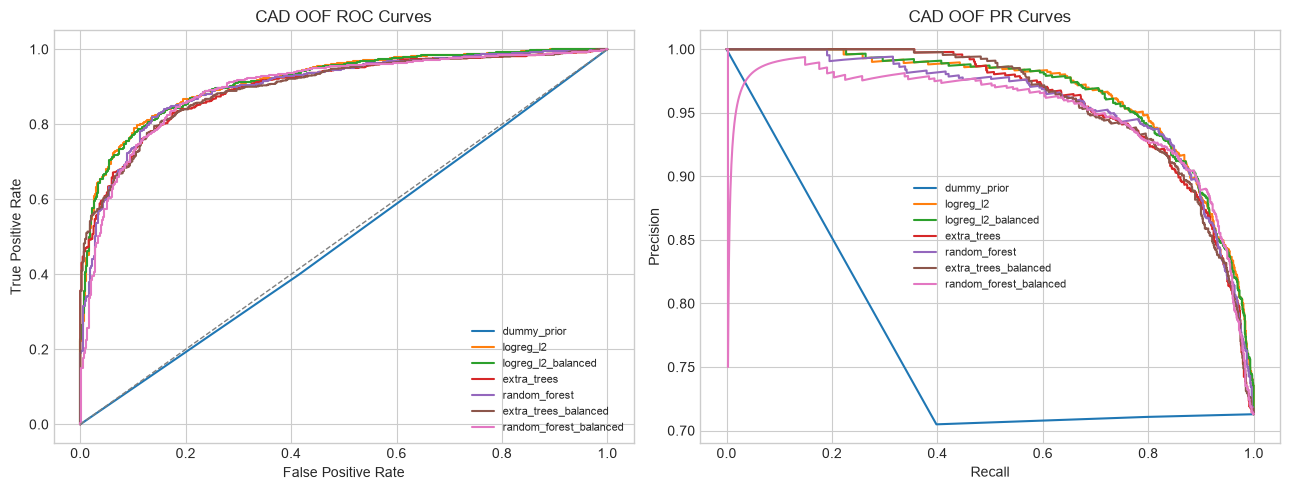

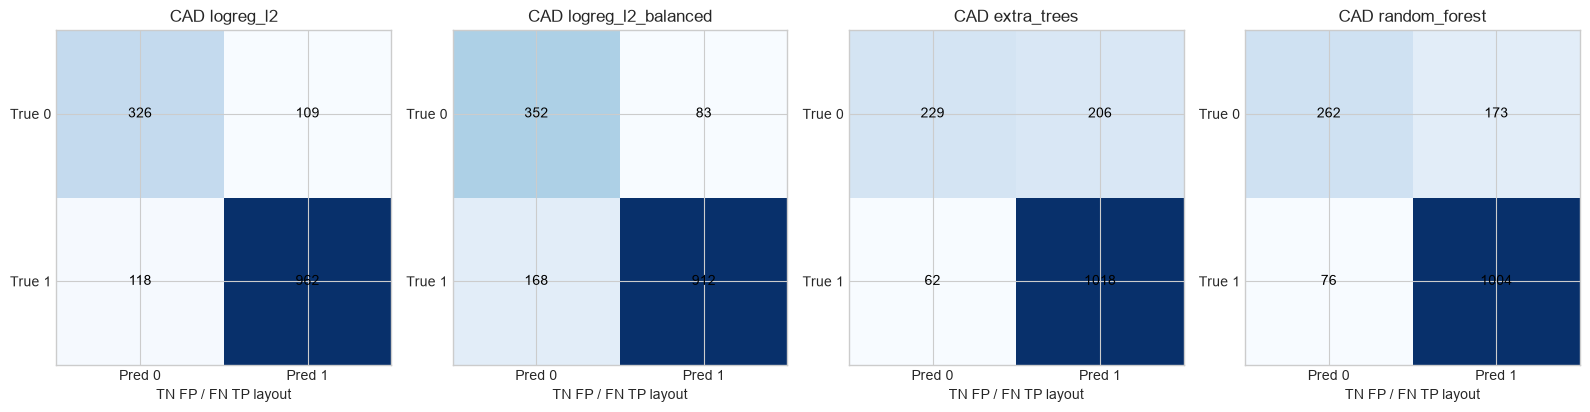

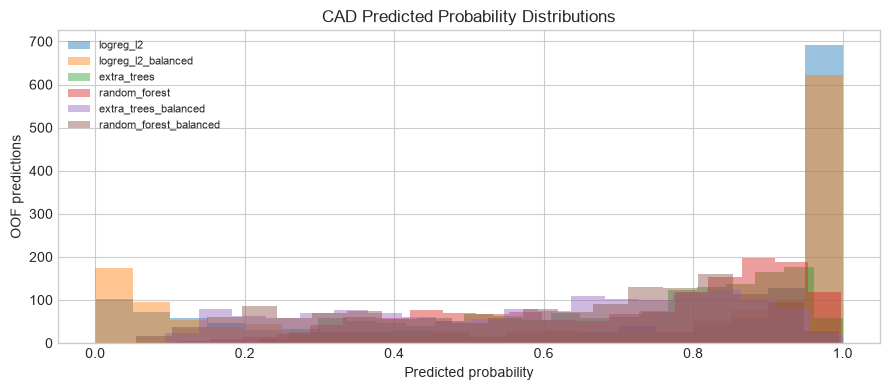

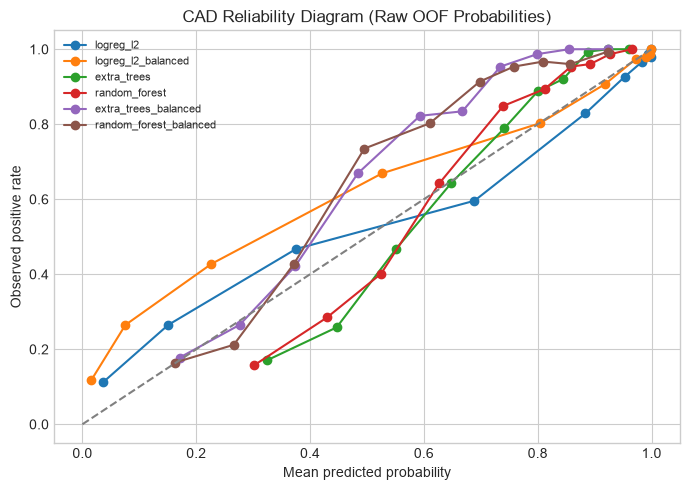

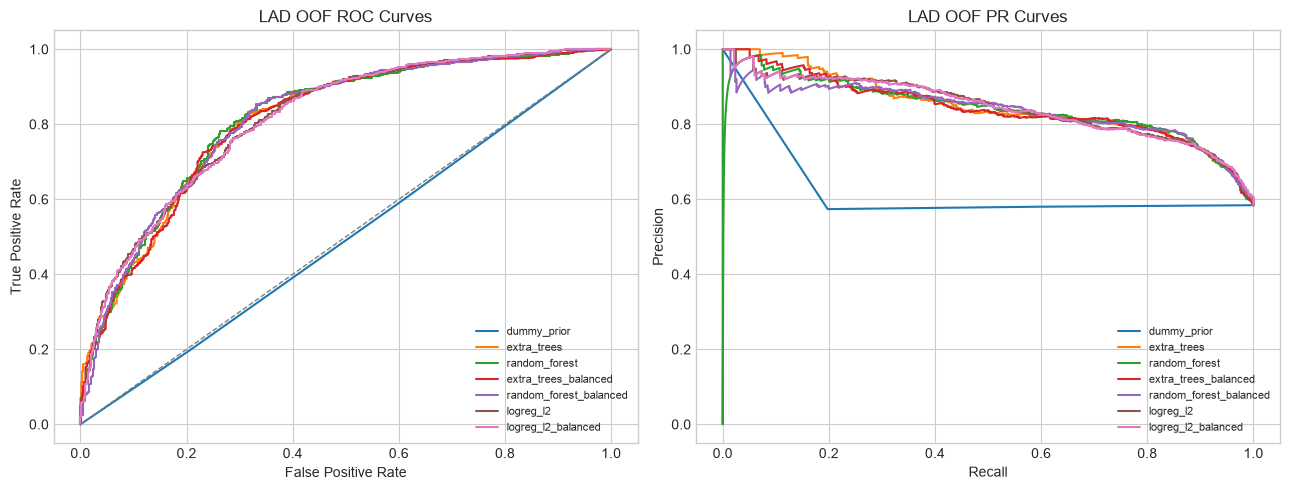

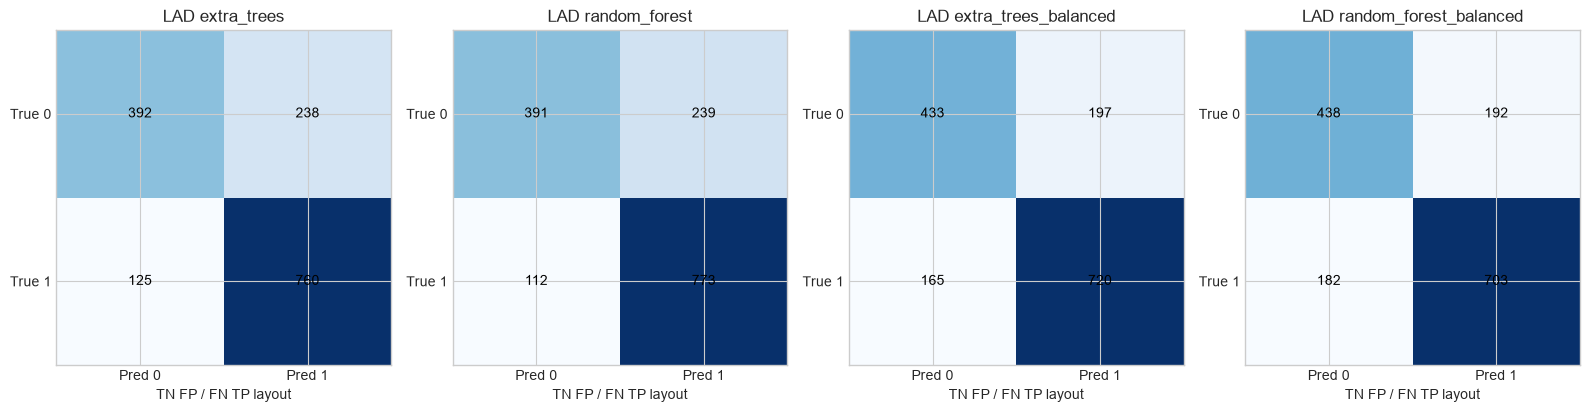

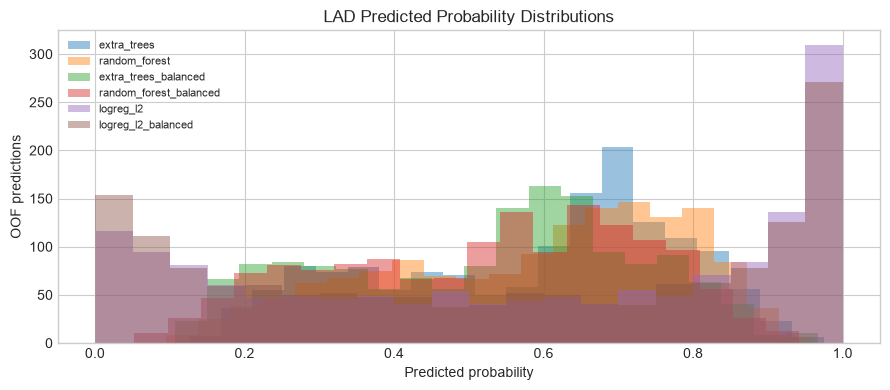

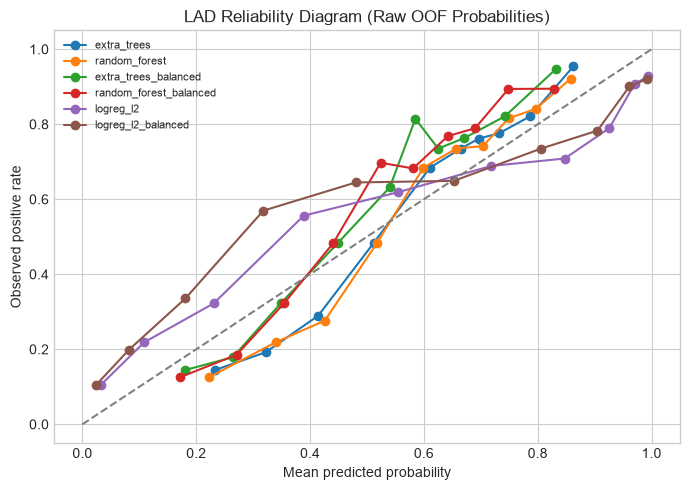

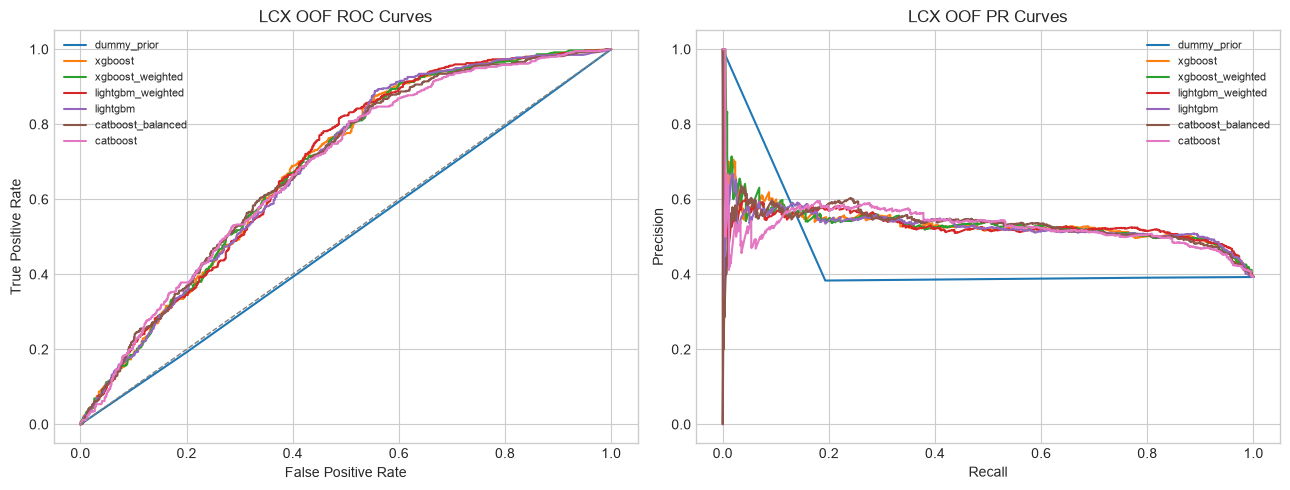

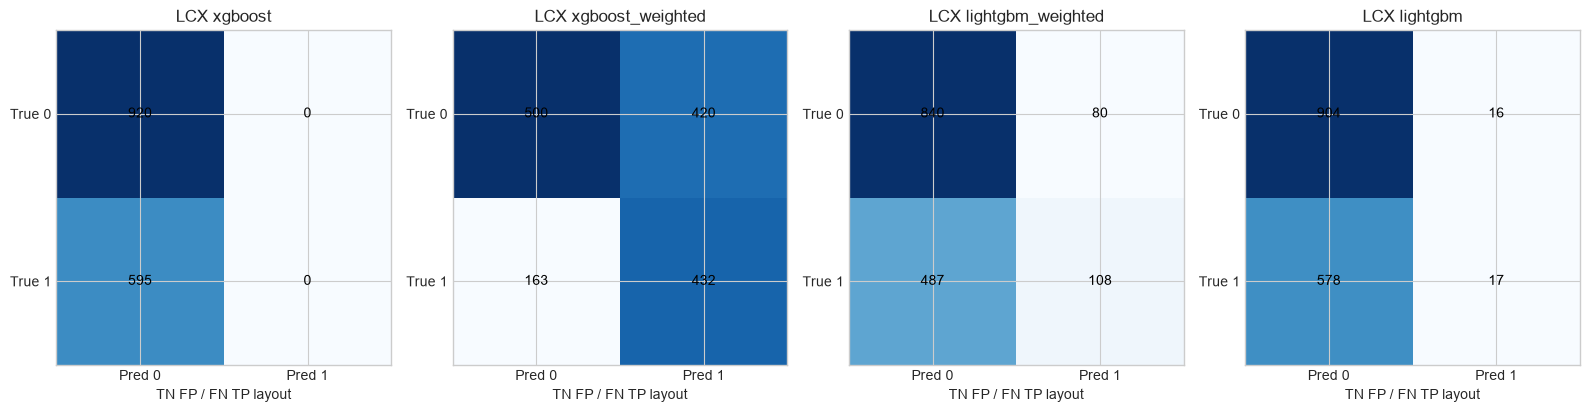

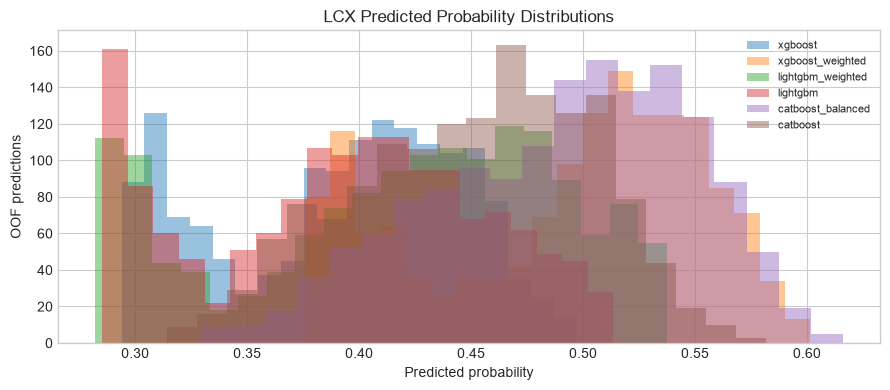

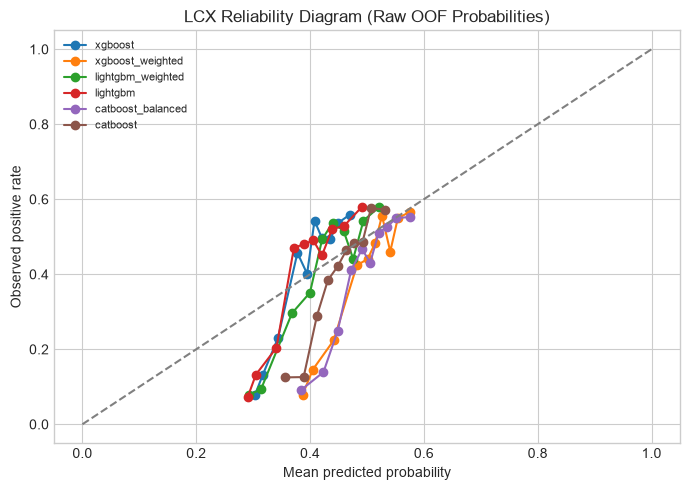

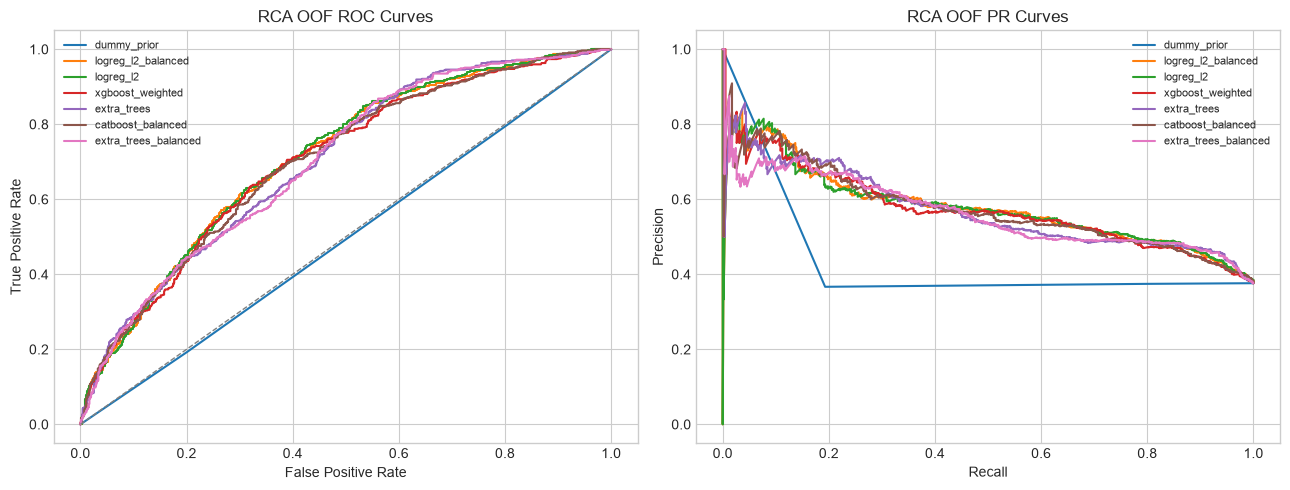

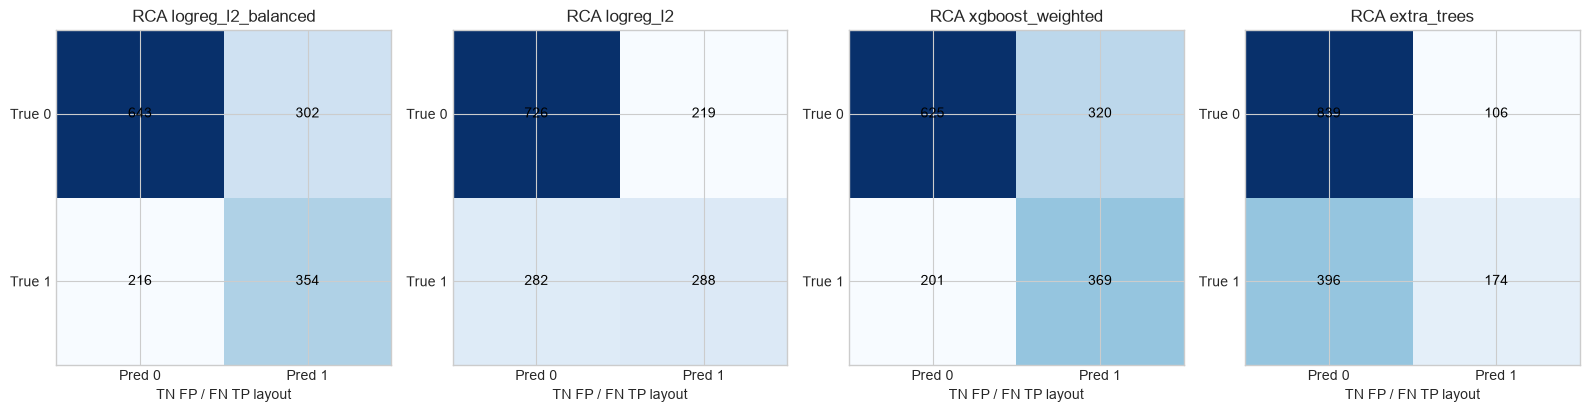

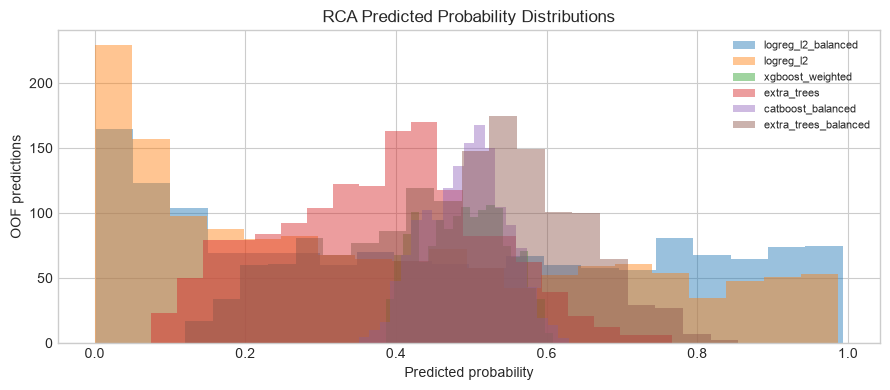

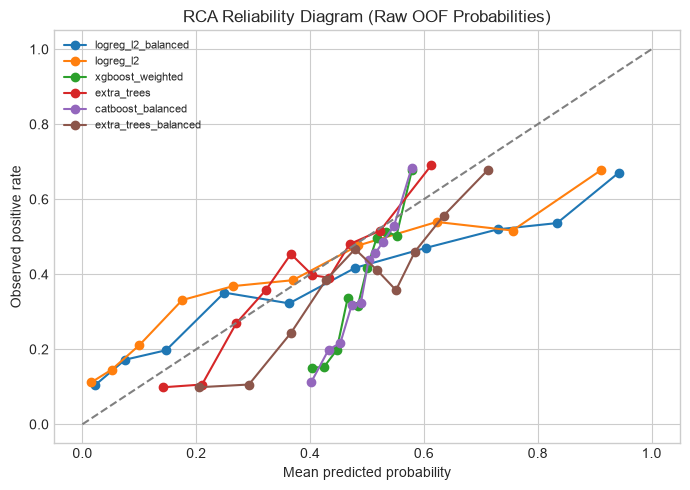

In [5]:
for target in TARGETS:
    serious = baseline_summary[(baseline_summary["target"] == target) & (baseline_summary["model"].isin(SERIOUS_MODELS))]
    plot_models = serious.sort_values("roc_auc_mean", ascending=False).head(6)["model"].tolist()
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for model in ["dummy_prior"] + plot_models:
        pred = oof_predictions[(oof_predictions["target"] == target) & (oof_predictions["model"] == model)]
        if pred.empty:
            continue
        fpr, tpr, _ = roc_curve(pred["true_label"], pred["predicted_probability"])
        precision, recall, _ = precision_recall_curve(pred["true_label"], pred["predicted_probability"])
        axes[0].plot(fpr, tpr, label=model)
        axes[1].plot(recall, precision, label=model)
    axes[0].plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
    axes[0].set_title(f"{target.upper()} OOF ROC Curves")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[1].set_title(f"{target.upper()} OOF PR Curves")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    for ax in axes:
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, min(4, len(plot_models)), figsize=(4 * min(4, len(plot_models)), 4))
    axes = np.atleast_1d(axes)
    for ax, model in zip(axes, plot_models[:4]):
        pred = oof_predictions[(oof_predictions["target"] == target) & (oof_predictions["model"] == model)]
        cm = confusion_matrix(pred["true_label"], pred["predicted_class"], labels=[0, 1])
        ax.imshow(cm, cmap="Blues")
        ax.set_title(f"{target.upper()} {model}")
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["True 0", "True 1"])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
        ax.set_xlabel("TN FP / FN TP layout")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4))
    for model in plot_models[:6]:
        pred = oof_predictions[(oof_predictions["target"] == target) & (oof_predictions["model"] == model)]
        ax.hist(pred["predicted_probability"], bins=20, alpha=0.45, label=model)
    ax.set_title(f"{target.upper()} Predicted Probability Distributions")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("OOF predictions")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 5))
    for model in plot_models[:6]:
        pred = oof_predictions[(oof_predictions["target"] == target) & (oof_predictions["model"] == model)].copy()
        pred["bin"] = pd.qcut(pred["predicted_probability"].rank(method="first"), q=10, duplicates="drop")
        curve = pred.groupby("bin", observed=False).agg(mean_probability=("predicted_probability", "mean"), observed_rate=("true_label", "mean")).dropna()
        ax.plot(curve["mean_probability"], curve["observed_rate"], marker="o", label=model)
    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.set_title(f"{target.upper()} Reliability Diagram (Raw OOF Probabilities)")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed positive rate")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## Paired Fold Differences and Sanity Checks

In [6]:
paired_difference_rows = []
for target in TARGETS:
    candidates = baseline_summary[(baseline_summary["target"] == target) & (baseline_summary["model"].isin(SERIOUS_MODELS))].head(4)["model"].tolist()
    for i, model_a in enumerate(candidates):
        for model_b in candidates[i + 1:]:
            a = baseline_cv_metrics[(baseline_cv_metrics["target"] == target) & (baseline_cv_metrics["model"] == model_a)]
            b = baseline_cv_metrics[(baseline_cv_metrics["target"] == target) & (baseline_cv_metrics["model"] == model_b)]
            paired = a.merge(b, on=["target", "repeat", "fold"], suffixes=(f"_{model_a}", f"_{model_b}"))
            paired_difference_rows.append({
                "target": target, "model_a": model_a, "model_b": model_b, "metric": "roc_auc",
                "mean_difference_a_minus_b": (paired[f"roc_auc_{model_a}"] - paired[f"roc_auc_{model_b}"]).mean(),
                "std_difference": (paired[f"roc_auc_{model_a}"] - paired[f"roc_auc_{model_b}"]).std(ddof=1),
                "folds_a_better": int((paired[f"roc_auc_{model_a}"] > paired[f"roc_auc_{model_b}"]).sum()),
                "n_paired_folds": len(paired),
                "note": "Repeated CV folds are not fully independent; treat as stability evidence, not a definitive significance claim.",
            })
paired_model_differences = pd.DataFrame(paired_difference_rows)
display(paired_model_differences)

suspicious = baseline_summary[(baseline_summary["roc_auc_mean"] > 0.95) | (baseline_summary["accuracy_mean"] > 0.98)]
if not suspicious.empty:
    print("WARNING: suspiciously high performance found. Re-check leakage columns, preprocessing leakage, duplicate patients, accidental targets, CV implementation, and post-diagnostic variables.")
    display(suspicious)
else:
    print("No ROC-AUC > 0.95 or accuracy > 0.98 found in baseline summaries.")

assert FORBIDDEN_COLUMNS.isdisjoint(X.columns)
assert not X.duplicated().any(), "Duplicate patient feature rows found; investigate before notebook 04."
assert oof_predictions.groupby(["target", "model", "repeat"])["row_id"].nunique().min() == len(X)
print("Sanity checks passed: no forbidden predictor columns, no duplicate feature rows, and OOF coverage is complete per target/model/repeat.")

,target,model_a,model_b,metric,mean_difference_a_minus_b,std_difference,folds_a_better,n_paired_folds,note
0,cad,logreg_l2,logreg_l2_balanced,roc_auc,0.0011,0.0055,13,25,Repeated CV folds are not fully independent; t...
1,cad,logreg_l2,extra_trees,roc_auc,0.0124,0.0405,16,25,Repeated CV folds are not fully independent; t...
2,cad,logreg_l2,random_forest,roc_auc,0.0150,0.0382,16,25,Repeated CV folds are not fully independent; t...
3,cad,logreg_l2_balanced,extra_trees,roc_auc,0.0112,0.0389,16,25,Repeated CV folds are not fully independent; t...
4,cad,logreg_l2_balanced,random_forest,roc_auc,0.0138,0.0382,15,25,Repeated CV folds are not fully independent; t...
5,cad,extra_trees,random_forest,roc_auc,0.0026,0.0306,15,25,Repeated CV folds are not fully independent; t...
6,lad,extra_trees,random_forest,roc_auc,0.0008,0.0419,9,25,Repeated CV folds are not fully independent; t...
7,lad,extra_trees,extra_trees_balanced,roc_auc,0.0015,0.0132,13,25,Repeated CV folds are not fully independent; t...
8,lad,extra_trees,random_forest_balanced,roc_auc,0.0025,0.0391,12,25,Repeated CV folds are not fully independent; t...
9,lad,random_forest,extra_trees_balanced,roc_auc,0.0007,0.0437,13,25,Repeated CV folds are not fully independent; t...


No ROC-AUC > 0.95 or accuracy > 0.98 found in baseline summaries.
Sanity checks passed: no forbidden predictor columns, no duplicate feature rows, and OOF coverage is complete per target/model/repeat.


## Export Results

In [7]:
baseline_cv_metrics.to_csv(BASELINE_DIR / "baseline_cv_metrics.csv", index=False)
baseline_summary.to_csv(BASELINE_DIR / "baseline_summary.csv", index=False)
oof_predictions.to_csv(BASELINE_DIR / "oof_predictions.csv", index=False)
model_stability.to_csv(BASELINE_DIR / "model_stability.csv", index=False)
class_weight_comparison.to_csv(BASELINE_DIR / "class_weight_comparison.csv", index=False)
overfitting_flags.to_csv(BASELINE_DIR / "overfitting_flags.csv", index=False)

for filename in [
    "baseline_cv_metrics.csv",
    "baseline_summary.csv",
    "oof_predictions.csv",
    "model_stability.csv",
    "class_weight_comparison.csv",
    "overfitting_flags.csv",
]:
    path = BASELINE_DIR / filename
    assert path.exists(), f"Missing export: {path}"
    print(f"Saved {path.relative_to(PROJECT_ROOT)}")

Saved ml\artifacts\metrics\baselines\baseline_cv_metrics.csv
Saved ml\artifacts\metrics\baselines\baseline_summary.csv
Saved ml\artifacts\metrics\baselines\oof_predictions.csv
Saved ml\artifacts\metrics\baselines\model_stability.csv
Saved ml\artifacts\metrics\baselines\class_weight_comparison.csv
Saved ml\artifacts\metrics\baselines\overfitting_flags.csv


## Final Report

In [8]:
recommended_rows = []
for target in TARGETS:
    target_summary = baseline_summary[(baseline_summary["target"] == target) & (baseline_summary["model"].isin(SERIOUS_MODELS))].copy()
    target_summary["stability_penalty"] = target_summary["roc_auc_std"].fillna(0) + target_summary["f1_std"].fillna(0)
    target_summary = target_summary.sort_values(
        ["roc_auc_mean", "pr_auc_average_precision_mean", "f1_mean", "balanced_accuracy_mean", "brier_score_mean", "stability_penalty"],
        ascending=[False, False, False, False, True, True],
    )
    for rank, (_, row) in enumerate(target_summary.head(3).iterrows(), start=1):
        recommended_rows.append({
            "target": target,
            "rank": rank,
            "model": row["model"],
            "roc_auc_mean": row["roc_auc_mean"],
            "roc_auc_std": row["roc_auc_std"],
            "pr_auc_mean": row["pr_auc_average_precision_mean"],
            "pr_auc_std": row["pr_auc_average_precision_std"],
            "f1_mean": row["f1_mean"],
            "f1_std": row["f1_std"],
            "recall_mean": row["recall_sensitivity_mean"],
            "specificity_mean": row["specificity_mean"],
            "balanced_accuracy_mean": row["balanced_accuracy_mean"],
            "brier_score_mean": row["brier_score_mean"],
        })
recommended_candidates = pd.DataFrame(recommended_rows)

execution_seconds = time.perf_counter() - notebook_start
final_report = {
    "recommended_candidates_by_target": recommended_candidates.to_dict("records"),
    "most_stable_models": model_stability.sort_values(["high_instability_flag", "roc_auc_std", "f1_std"]).head(12).to_dict("records"),
    "models_showing_overfitting": overfitting_flags[overfitting_flags["overfitting_flag"]].to_dict("records"),
    "class_weighting_findings": class_weight_comparison.to_dict("records"),
    "probability_quality_observations": "Use Brier score, reliability diagrams, and probability histograms above. Raw probabilities are not calibrated in this notebook.",
    "suspicious_performance": baseline_summary[(baseline_summary["roc_auc_mean"] > 0.95) | (baseline_summary["accuracy_mean"] > 0.98)].to_dict("records"),
    "execution_seconds": execution_seconds,
}
display(recommended_candidates)
print(json.dumps(final_report, indent=2, default=str))
print("\nAll reported baseline validation predictions were generated out-of-fold with preprocessing fitted only on training folds.")

,target,rank,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,recall_mean,specificity_mean,balanced_accuracy_mean,brier_score_mean
0,cad,1,logreg_l2,0.9184,0.0339,0.9659,0.0150,0.8939,0.0315,0.8906,0.7499,0.8203,0.1087
1,cad,2,logreg_l2_balanced,0.9172,0.0355,0.9656,0.0153,0.8784,0.0357,0.8442,0.8097,0.8270,0.1171
2,cad,3,extra_trees,0.9060,0.0416,0.9623,0.0172,0.8836,0.0269,0.9425,0.5261,0.7343,0.1251
3,lad,1,extra_trees,0.8220,0.0556,0.8625,0.0463,0.8071,0.0379,0.8593,0.6226,0.7410,0.1750
4,lad,2,random_forest,0.8211,0.0555,0.8561,0.0552,0.8143,0.0474,0.8739,0.6210,0.7474,0.1750
5,lad,3,extra_trees_balanced,0.8205,0.0575,0.8582,0.0492,0.7985,0.0472,0.8143,0.6876,0.7510,0.1799
6,lcx,1,xgboost,0.6947,0.0747,0.5749,0.0812,0.0000,0.0000,0.0000,1.0000,0.5000,0.2240
7,lcx,2,xgboost_weighted,0.6937,0.0731,0.5726,0.0817,0.5951,0.0791,0.7259,0.5435,0.6347,0.2323
8,lcx,3,lightgbm_weighted,0.6931,0.0584,0.5647,0.0762,0.2697,0.0987,0.1811,0.9129,0.5470,0.2205
9,rca,1,logreg_l2_balanced,0.7126,0.0602,0.6050,0.0763,0.5746,0.0679,0.6209,0.6807,0.6508,0.2301


{
  "recommended_candidates_by_target": [
    {
      "target": "cad",
      "rank": 1,
      "model": "logreg_l2",
      "roc_auc_mean": 0.9183533004463239,
      "roc_auc_std": 0.03389840030423683,
      "pr_auc_mean": 0.9658656508441915,
      "pr_auc_std": 0.014973447873504625,
      "f1_mean": 0.893906573668001,
      "f1_std": 0.031549689946481246,
      "recall_mean": 0.8906342494714589,
      "specificity_mean": 0.7499346405228757,
      "balanced_accuracy_mean": 0.8202844449971675,
      "brier_score_mean": 0.1086689911447147
    },
    {
      "target": "cad",
      "rank": 2,
      "model": "logreg_l2_balanced",
      "roc_auc_mean": 0.9172421893352127,
      "roc_auc_std": 0.035454591868061366,
      "pr_auc_mean": 0.9655947034657393,
      "pr_auc_std": 0.015264171452157478,
      "f1_mean": 0.8784367313475966,
      "f1_std": 0.03565944233511354,
      "recall_mean": 0.8442494714587737,
      "specificity_mean": 0.809673202614379,
      "balanced_accuracy_mean": 0.8269613